<a href="https://colab.research.google.com/github/shreyoshi2304/Dataset-Analysis-/blob/main/RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Supervised Machine Learning with Random Forest Algorithm in Python

In [ ]:
#Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Social_Network_Ads.csv')

In [ ]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=0)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
#.fit finds the mean and standard deviation for each column and _transform substract the mean from the data point of each column and divides by SD
X_test = sc.transform(X_test) # here we only require transform as the scaler is already FIT to training data's statistics

In [ ]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators=10,criterion='entropy',random_state=0) #n_estimators are the number of decision trees ;
#entropy criterion uses information gain for split
classifier.fit(X_train,y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

In [ ]:
print(classifier.predict(sc.transform([[30,87000]])))

[0]


In [ ]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1),y_test.reshape(len(y_test),1)),1))

[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]]


In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm = confusion_matrix(y_test,y_pred)
print(cm)
accuracy_score(y_test,y_pred)

[[63  5]
 [ 4 28]]


0.91

/tmp/ipython-input-3466728014.py:52: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j,0],X_set[y_set == j,1],c = ListedColormap(('red','green'))(i),label=j)


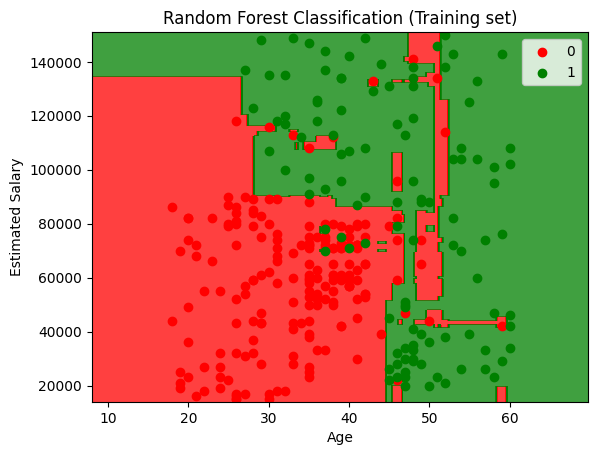

In [ ]:
from matplotlib.colors import ListedColormap
X_set , y_set = sc.inverse_transform(X_train), y_train # Converts them back to "unscaled" data
# Create a meshgrid of values spanning the feature space (Age vs Salary)

X1, X2 = np.meshgrid(
    # For the Age axis (feature 0)
    np.arange(
        start = X_set[:, 0].min() - 10,   # minimum Age value (with margin of -10)
        stop  = X_set[:, 0].max() + 10,   # maximum Age value (with margin of +10)
        step  = 0.25                      # resolution/step size → smaller = smoother boundary
    ),
    # For the Salary axis (feature 1)
    np.arange(
        start = X_set[:, 1].min() - 1000, # minimum Salary value (with margin of -1000)
        stop  = X_set[:, 1].max() + 1000, # maximum Salary value (with margin of +1000)
        step  = 0.25                      # resolution of grid along Salary
    )
)
# 👉 np.meshgrid creates two 2D arrays (X1, X2) representing all coordinate pairs
#    Example: If X1 is [[20, 21, 22], [20, 21, 22]], then X2 is [[30, 30, 30], [31, 31, 31]]
#    Together, they represent a grid of points in the (Age, Salary) plane.


# Plot the decision regions using contourf
plt.contourf(
    X1,
    X2,
    # Predict class labels for every point in the grid
    classifier.predict(
        sc.transform(
            np.array([X1.ravel(), X2.ravel()]).T
        )
    ).reshape(X1.shape),

    # Make regions semi-transparent so scatter points are visible
    alpha = 0.75,

    # Define custom colors: red for class 0, green for class 1
    cmap = ListedColormap(('red', 'green'))
)

# Explanation of the inner part:
# - X1.ravel(), X2.ravel() → flatten the grid into long 1D arrays
# - np.array([X1.ravel(), X2.ravel()]).T → combine into N x 2 array (list of all [Age, Salary] points)
# - sc.transform(...) → scale grid points (because classifier was trained on scaled features)
# - classifier.predict(...) → get predicted class (0/1) for each point
# - reshape(X1.shape) → convert predictions back into same 2D grid shape so contourf can color regions

plt.xlim(X1.min(),X1.max())
plt.ylim(X2.min(),X2.max())
for i,j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j,0],X_set[y_set == j,1],c = ListedColormap(('red','green'))(i),label=j)
plt.title("Random Forest Classification (Training set)")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.legend()
plt.show()

/tmp/ipython-input-1725080518.py:52: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j,0],X_set[y_set == j,1],c = ListedColormap(('red','green'))(i),label=j)


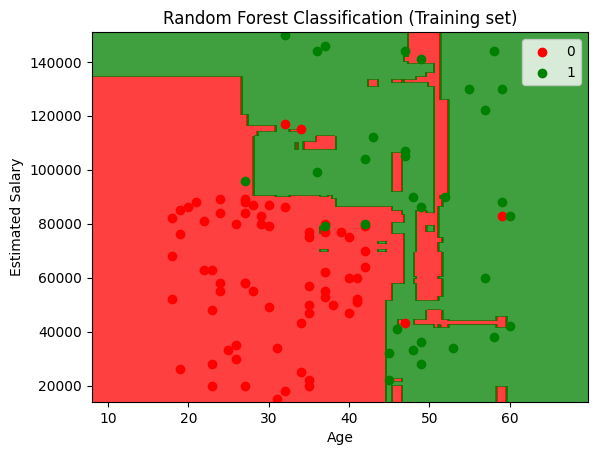

In [ ]:
from matplotlib.colors import ListedColormap
X_set , y_set = sc.inverse_transform(X_test), y_test # Converts them back to "unscaled" data
# Create a meshgrid of values spanning the feature space (Age vs Salary)

X1, X2 = np.meshgrid(
    # For the Age axis (feature 0)
    np.arange(
        start = X_set[:, 0].min() - 10,   # minimum Age value (with margin of -10)
        stop  = X_set[:, 0].max() + 10,   # maximum Age value (with margin of +10)
        step  = 0.25                      # resolution/step size → smaller = smoother boundary
    ),
    # For the Salary axis (feature 1)
    np.arange(
        start = X_set[:, 1].min() - 1000, # minimum Salary value (with margin of -1000)
        stop  = X_set[:, 1].max() + 1000, # maximum Salary value (with margin of +1000)
        step  = 0.25                      # resolution of grid along Salary
    )
)
# 👉 np.meshgrid creates two 2D arrays (X1, X2) representing all coordinate pairs
#    Example: If X1 is [[20, 21, 22], [20, 21, 22]], then X2 is [[30, 30, 30], [31, 31, 31]]
#    Together, they represent a grid of points in the (Age, Salary) plane.


# Plot the decision regions using contourf
plt.contourf(
    X1,
    X2,
    # Predict class labels for every point in the grid
    classifier.predict(
        sc.transform(
            np.array([X1.ravel(), X2.ravel()]).T
        )
    ).reshape(X1.shape),

    # Make regions semi-transparent so scatter points are visible
    alpha = 0.75,

    # Define custom colors: red for class 0, green for class 1
    cmap = ListedColormap(('red', 'green'))
)

# Explanation of the inner part:
# - X1.ravel(), X2.ravel() → flatten the grid into long 1D arrays
# - np.array([X1.ravel(), X2.ravel()]).T → combine into N x 2 array (list of all [Age, Salary] points)
# - sc.transform(...) → scale grid points (because classifier was trained on scaled features)
# - classifier.predict(...) → get predicted class (0/1) for each point
# - reshape(X1.shape) → convert predictions back into same 2D grid shape so contourf can color regions

plt.xlim(X1.min(),X1.max())
plt.ylim(X2.min(),X2.max())
for i,j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j,0],X_set[y_set == j,1],c = ListedColormap(('red','green'))(i),label=j)
plt.title("Random Forest Classification (Training set)")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.legend()
plt.show()